# 3. Alpha Particle Attenuation in Matter

**Objective:** Study energy loss of alpha particles using calibrated energy spectra. Compare alpha energies with and without matter at different distances, analyzing energy attenuation patterns.

**Analysis:**
- Convert all AM spectrum files to energy using calibration from 01_energy_calibration.ipynb
- Extract peak energies (with/without matter) at distances: 1 cm, 5 cm, and ultimate distance
- Compare energy loss at same distances
- Compare energy variation across distances at same matter condition

## Setup and Helper Functions

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

DATA_DIR = Path('.')

def load_alpha_spectrum_file(file_path):
    """Load alpha spectroscopy MCA data file.
    Returns: (channel_array, counts_array)
    """
    text = Path(file_path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []
    
    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

# Bragg-Kleeman stopping power rule for alphas in air
# Approximate energy loss per unit distance (low energy approximation)
def stopping_power_air(E_mev):
    """
    Approximate stopping power for alphas in air (dE/dx).
    E_mev: energy in MeV
    Returns: stopping power in MeV/cm
    """
    # Empirical formula for alpha stopping power in air at 15°C, 760 mmHg
    # dE/dx ≈ 1.24 × E^(-0.5) - 0.0026 for 1-10 MeV (Bragg-Kleeman rule)
    if E_mev < 1:
        return 1.24 * np.sqrt(E_mev) - 0.0026
    elif E_mev < 10:
        return 1.24 * np.power(E_mev, -0.5) - 0.0026
    else:
        return 0.0

print('Setup complete. Attenuation analysis functions loaded.')

Setup complete. Attenuation analysis functions loaded.


## 3.1 Spectrum with Vacuum (Reference)

In [12]:
# ==========================================
# CALIBRATION PARAMETERS FROM 01_energy_calibration.ipynb
# ==========================================
# Energy calibration: E(C) = m * C + b
# Which is equivalent to: E(C) = m * (C - c_zero)
ganho_energia = 0.002207        # MeV/channel (slope)
b_energia = 4.550794            # MeV (intercept)
c_zero_weighted = -2061.60      # channel offset (electronic zero)
sigma_ganho = 0.000001          # MeV/channel
sigma_b = 0.001064              # MeV

print("="*70)
print("CALIBRATION PARAMETERS FROM PULSER CALIBRATION")
print("="*70)
print(f"\nCalibration Equation: E(C) = {ganho_energia:.6f} × C + {b_energia:.6f} MeV")
print(f"OR equivalently:      E(C) = {ganho_energia:.6f} × (C - ({c_zero_weighted:.2f})) MeV")
print(f"  Slope (m):     {ganho_energia:.6f} ± {sigma_ganho:.6f} MeV/channel")
print(f"  Intercept (b): {b_energia:.6f} ± {sigma_b:.6f} MeV")
print(f"  Channel offset (C₀): {c_zero_weighted:.2f} channels")
print("\nThese calibration parameters will be used to convert ALL channel data to energy.")

def energy_from_channel(channel, sigma_channel=0):
    """Convert channel to energy with uncertainty propagation.
    Uses: E = m * C + b (where b = -m * c_zero)
    """
    E = ganho_energia * channel + b_energia
    if sigma_channel > 0:
        sigma_E = np.sqrt((sigma_ganho * channel)**2 + 
                          (ganho_energia * sigma_channel)**2 + 
                          sigma_b**2)
        return E, sigma_E
    return E, 0


CALIBRATION PARAMETERS FROM PULSER CALIBRATION

Calibration Equation: E(C) = 0.002207 × C + 4.550794 MeV
OR equivalently:      E(C) = 0.002207 × (C - (-2061.60)) MeV
  Slope (m):     0.002207 ± 0.000001 MeV/channel
  Intercept (b): 4.550794 ± 0.001064 MeV
  Channel offset (C₀): -2061.60 channels

These calibration parameters will be used to convert ALL channel data to energy.


## 3.2 Alpha Source Attenuation: AM Files Analysis

File naming convention:
- **AM**: Alpha element
- **M**: With matter (material present)
- **SM**: Without matter (sem = without in Portuguese)
- **1, 5, ULT**: Distance codes (1 cm, 5 cm, ultimate/far distance)

Measurement pairs:
- **AMM1 vs AMSM1**: With/without matter at distance 1
- **AMM5 vs AMSM5**: With/without matter at distance 5
- **AMMULT vs AMSMULT**: With/without matter at ultimate distance

In [13]:
# ==========================================
# LOAD AM FILES AND EXTRACT PEAK CENTROIDS
# ==========================================

def extract_peak_centroid(channels, counts, channel_min=None, channel_max=None):
    """Extract peak centroid from spectrum region.
    If channel_min/max not specified, finds the max count and works around it."""
    
    if channel_min is not None and channel_max is not None:
        mask = (channels >= channel_min) & (channels <= channel_max)
    else:
        # Use full spectrum
        mask = np.ones(len(channels), dtype=bool)
    
    region_channels = channels[mask]
    region_counts = counts[mask]
    
    if np.sum(region_counts) == 0:
        return None, None, None
    
    centroid = np.sum(region_channels * region_counts) / np.sum(region_counts)
    
    # Uncertainty in centroid from counting statistics
    total_counts = np.sum(region_counts)
    peak_sigma_sq = np.sum(region_counts * (region_channels - centroid)**2) / total_counts
    peak_sigma = np.sqrt(peak_sigma_sq)
    sigma_centroid = peak_sigma / np.sqrt(total_counts)
    
    return centroid, sigma_centroid, total_counts

def extract_peak_region(channels, counts, width=20):
    """Find main peak and extract centroid from region around it."""
    # Find maximum
    max_idx = np.argmax(counts)
    peak_ch = channels[max_idx]
    
    # Define region around peak
    channel_min = max(0, peak_ch - width)
    channel_max = min(1024, peak_ch + width)
    
    return extract_peak_centroid(channels, counts, channel_min, channel_max)

# Define files and their distance labels
am_files = {
    'AMM1.ASC': ('With Matter', 'Distance 1'),
    'AMM5.ASC': ('With Matter', 'Distance 5'),
    'AMMULT.ASC': ('With Matter', 'Distance Ultimate'),
    'AMSM1.ASC': ('Without Matter', 'Distance 1'),
    'AMSM5.ASC': ('Without Matter', 'Distance 5'),
    'AMSMULT.ASC': ('Without Matter', 'Distance Ultimate'),
}

# Load all files and extract peaks
print("="*70)
print("LOADING AM FILES AND EXTRACTING PEAK CENTROIDS")
print("="*70)

am_data = {}
for filename, (matter_status, distance_label) in am_files.items():
    try:
        channels, counts = load_alpha_spectrum_file(DATA_DIR / filename)
        centroid_ch, sigma_centroid_ch, total_counts = extract_peak_region(
            channels, counts, width=30  # ±30 channels around peak
        )
        
        if centroid_ch is not None:
            energy, sigma_energy = energy_from_channel(centroid_ch, sigma_centroid_ch)
            am_data[filename] = {
                'channels': channels,
                'counts': counts,
                'centroid_ch': centroid_ch,
                'sigma_centroid_ch': sigma_centroid_ch,
                'total_counts': total_counts,
                'energy': energy,
                'sigma_energy': sigma_energy,
                'matter': matter_status,
                'distance': distance_label
            }
            
            print(f"\n{filename}")
            print(f"  Status: {matter_status}, {distance_label}")
            print(f"  Peak: {centroid_ch:.2f} ± {sigma_centroid_ch:.3f} ch → {energy:.4f} ± {sigma_energy:.4f} MeV")
            print(f"  Total counts in region: {total_counts:.0f}")
    except Exception as e:
        print(f"\nERROR loading {filename}: {e}")

print("\n" + "="*70)


LOADING AM FILES AND EXTRACTING PEAK CENTROIDS

AMM1.ASC
  Status: With Matter, Distance 1
  Peak: 635.83 ± 0.035 ch → 5.9541 ± 0.0012 MeV
  Total counts in region: 69769

AMM5.ASC
  Status: With Matter, Distance 5
  Peak: 431.85 ± 0.097 ch → 5.5039 ± 0.0012 MeV
  Total counts in region: 6961

AMMULT.ASC
  Status: With Matter, Distance Ultimate
  Peak: 13.08 ± 0.259 ch → 4.5797 ± 0.0012 MeV
  Total counts in region: 179

AMSM1.ASC
  Status: Without Matter, Distance 1
  Peak: 698.00 ± 0.016 ch → 6.0913 ± 0.0013 MeV
  Total counts in region: 97468

AMSM5.ASC
  Status: Without Matter, Distance 5
  Peak: 699.73 ± 0.049 ch → 6.0951 ± 0.0013 MeV
  Total counts in region: 7858

AMSMULT.ASC
  Status: Without Matter, Distance Ultimate
  Peak: 699.62 ± 0.094 ch → 6.0949 ± 0.0013 MeV
  Total counts in region: 2088



## 3.3 Energy Loss Comparison: With vs Without Matter

Compare alpha particle energies at the same distance with and without matter. The energy loss (ΔE) reflects attenuation in the material.

In [14]:
# ==========================================
# COMPARISON 1: WITH vs WITHOUT MATTER (Same Distance)
# ==========================================

print("="*70)
print("COMPARISON 1: ENERGY LOSS AT SAME DISTANCES")
print("="*70)
print("\nComparing alpha energies WITH matter vs WITHOUT matter:")
print("ΔE = E(without matter) - E(with matter)\n")

distance_pairs = [
    ('Distance 1', 'AMSM1.ASC', 'AMM1.ASC'),
    ('Distance 5', 'AMSM5.ASC', 'AMM5.ASC'),
    ('Distance Ultimate', 'AMSMULT.ASC', 'AMMULT.ASC'),
]

energy_loss_data = {}
for dist_label, without_file, with_file in distance_pairs:
    if without_file in am_data and with_file in am_data:
        without_data = am_data[without_file]
        with_data = am_data[with_file]
        
        E_without = without_data['energy']
        sigma_E_without = without_data['sigma_energy']
        E_with = with_data['energy']
        sigma_E_with = with_data['sigma_energy']
        
        # Energy loss
        delta_E = E_without - E_with
        sigma_delta_E = np.sqrt(sigma_E_without**2 + sigma_E_with**2)
        
        # Energy loss percentage
        loss_percent = 100 * delta_E / E_without if E_without > 0 else 0
        
        energy_loss_data[dist_label] = {
            'E_without': E_without,
            'sigma_E_without': sigma_E_without,
            'E_with': E_with,
            'sigma_E_with': sigma_E_with,
            'delta_E': delta_E,
            'sigma_delta_E': sigma_delta_E,
            'loss_percent': loss_percent
        }
        
        print(f"\n{dist_label}:")
        print(f"  WITHOUT matter: {E_without:.4f} ± {sigma_E_without:.4f} MeV")
        print(f"  WITH matter:    {E_with:.4f} ± {sigma_E_with:.4f} MeV")
        print(f"  Energy loss (ΔE): {delta_E:.4f} ± {sigma_delta_E:.4f} MeV ({loss_percent:.2f}%)")
    else:
        missing = []
        if without_file not in am_data:
            missing.append(without_file)
        if with_file not in am_data:
            missing.append(with_file)
        print(f"\n{dist_label}: Missing files - {missing}")

print("\n" + "="*70)


COMPARISON 1: ENERGY LOSS AT SAME DISTANCES

Comparing alpha energies WITH matter vs WITHOUT matter:
ΔE = E(without matter) - E(with matter)


Distance 1:
  WITHOUT matter: 6.0913 ± 0.0013 MeV
  WITH matter:    5.9541 ± 0.0012 MeV
  Energy loss (ΔE): 0.1372 ± 0.0018 MeV (2.25%)

Distance 5:
  WITHOUT matter: 6.0951 ± 0.0013 MeV
  WITH matter:    5.5039 ± 0.0012 MeV
  Energy loss (ΔE): 0.5912 ± 0.0017 MeV (9.70%)

Distance Ultimate:
  WITHOUT matter: 6.0949 ± 0.0013 MeV
  WITH matter:    4.5797 ± 0.0012 MeV
  Energy loss (ΔE): 1.5152 ± 0.0018 MeV (24.86%)



In [15]:

# ==========================================
# COMPARISON 2: DISTANCE VARIATION (Same Matter Condition)
# ==========================================

print("="*70)
print("COMPARISON 2: DISTANCE VARIATION (Energy Trends)")
print("="*70)

# Analyze distance effects for WITH matter
print("\n--- WITH MATTER (different distances) ---")
with_matter_distances = {
    'Distance 1': am_data.get('AMM1.ASC'),
    'Distance 5': am_data.get('AMM5.ASC'),
    'Distance Ultimate': am_data.get('AMMULT.ASC'),
}

with_matter_energies = {}
for dist, data in with_matter_distances.items():
    if data:
        with_matter_energies[dist] = (data['energy'], data['sigma_energy'])
        print(f"{dist}: {data['energy']:.4f} ± {data['sigma_energy']:.4f} MeV")

# Analyze distance effects for WITHOUT matter
print("\n--- WITHOUT MATTER (different distances) ---")
without_matter_distances = {
    'Distance 1': am_data.get('AMSM1.ASC'),
    'Distance 5': am_data.get('AMSM5.ASC'),
    'Distance Ultimate': am_data.get('AMSMULT.ASC'),
}

without_matter_energies = {}
for dist, data in without_matter_distances.items():
    if data:
        without_matter_energies[dist] = (data['energy'], data['sigma_energy'])
        print(f"{dist}: {data['energy']:.4f} ± {data['sigma_energy']:.4f} MeV")

print("\n" + "="*70)


COMPARISON 2: DISTANCE VARIATION (Energy Trends)

--- WITH MATTER (different distances) ---
Distance 1: 5.9541 ± 0.0012 MeV
Distance 5: 5.5039 ± 0.0012 MeV
Distance Ultimate: 4.5797 ± 0.0012 MeV

--- WITHOUT MATTER (different distances) ---
Distance 1: 6.0913 ± 0.0013 MeV
Distance 5: 6.0951 ± 0.0013 MeV
Distance Ultimate: 6.0949 ± 0.0013 MeV



## 3.4 Summary Tables and Visualizations

In [16]:

# ==========================================
# SUMMARY TABLE 1: All measurements in energy
# ==========================================
import pandas as pd

print("="*70)
print("TABLE 1: ALL MEASUREMENTS IN ENERGY")
print("="*70 + "\n")

# Create summary dataframe
summary_data = []
for filename, data in sorted(am_data.items()):
    summary_data.append({
        'File': filename,
        'Matter': data['matter'],
        'Distance': data['distance'],
        'Peak (ch)': f"{data['centroid_ch']:.1f} ± {data['sigma_centroid_ch']:.2f}",
        'Energy (MeV)': f"{data['energy']:.4f} ± {data['sigma_energy']:.4f}",
        'Total Counts': f"{data['total_counts']:.0f}"
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

# ==========================================
# SUMMARY TABLE 2: Energy loss comparison
# ==========================================
print("\n" + "="*70)
print("TABLE 2: ENERGY LOSS (With vs Without Matter)")
print("="*70 + "\n")

loss_summary = []
for dist_label, loss_data in energy_loss_data.items():
    loss_summary.append({
        'Distance': dist_label,
        'E (no matter, MeV)': f"{loss_data['E_without']:.4f} ± {loss_data['sigma_E_without']:.4f}",
        'E (matter, MeV)': f"{loss_data['E_with']:.4f} ± {loss_data['sigma_E_with']:.4f}",
        'ΔE (MeV)': f"{loss_data['delta_E']:.4f} ± {loss_data['sigma_delta_E']:.4f}",
        'Loss %': f"{loss_data['loss_percent']:.2f}%"
    })

df_loss = pd.DataFrame(loss_summary)
print(df_loss.to_string(index=False))

print("\n" + "="*70)


TABLE 1: ALL MEASUREMENTS IN ENERGY

       File         Matter          Distance    Peak (ch)    Energy (MeV) Total Counts
   AMM1.ASC    With Matter        Distance 1 635.8 ± 0.03 5.9541 ± 0.0012        69769
   AMM5.ASC    With Matter        Distance 5 431.8 ± 0.10 5.5039 ± 0.0012         6961
 AMMULT.ASC    With Matter Distance Ultimate  13.1 ± 0.26 4.5797 ± 0.0012          179
  AMSM1.ASC Without Matter        Distance 1 698.0 ± 0.02 6.0913 ± 0.0013        97468
  AMSM5.ASC Without Matter        Distance 5 699.7 ± 0.05 6.0951 ± 0.0013         7858
AMSMULT.ASC Without Matter Distance Ultimate 699.6 ± 0.09 6.0949 ± 0.0013         2088

TABLE 2: ENERGY LOSS (With vs Without Matter)

         Distance E (no matter, MeV) E (matter, MeV)        ΔE (MeV) Loss %
       Distance 1    6.0913 ± 0.0013 5.9541 ± 0.0012 0.1372 ± 0.0018  2.25%
       Distance 5    6.0951 ± 0.0013 5.5039 ± 0.0012 0.5912 ± 0.0017  9.70%
Distance Ultimate    6.0949 ± 0.0013 4.5797 ± 0.0012 1.5152 ± 0.0018 24.86%



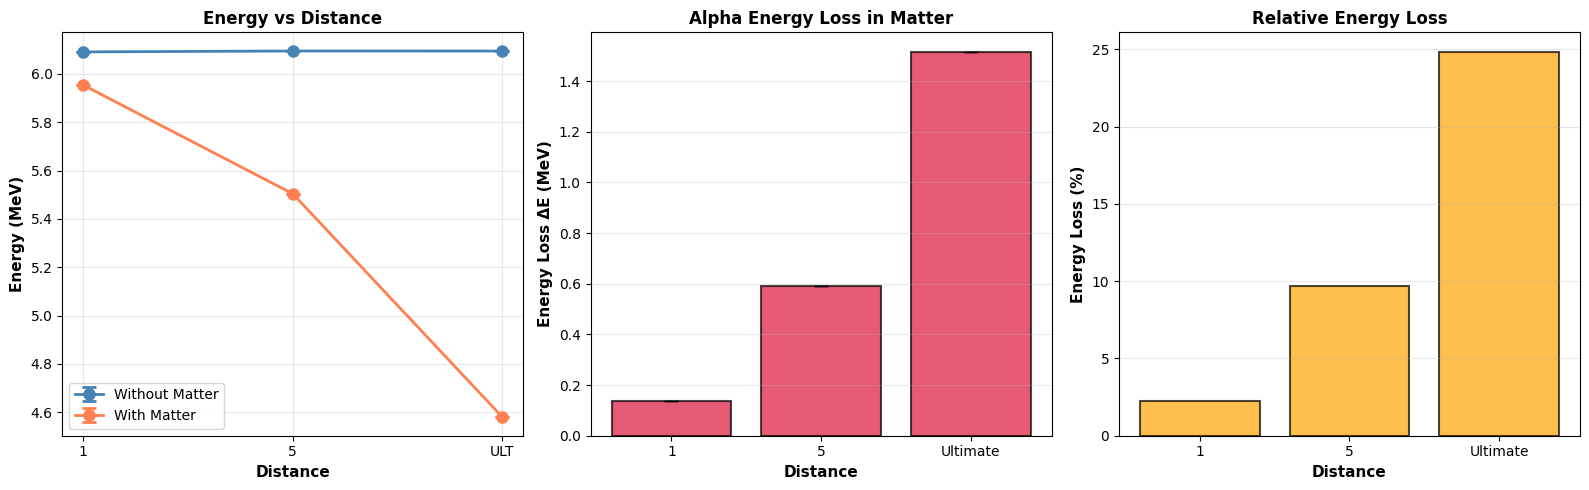

Energy comparison visualization complete.


In [17]:

# ==========================================
# VISUALIZATION 1: Energy Loss by Distance
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

distances_list = ['Distance 1', 'Distance 5', 'Distance Ultimate']
colors_matter = {'With Matter': 'coral', 'Without Matter': 'steelblue'}

# Plot 1: Energy values by distance
ax = axes[0]
for matter_type in ['Without Matter', 'With Matter']:
    energies = []
    errors = []
    labels_plot = []
    
    for dist in distances_list:
        if matter_type == 'Without Matter':
            file_key = f'AMSM{dist.split()[-1].lower()}.asc' if dist != 'Distance Ultimate' else 'AMSMULT.ASC'
        else:
            file_key = f'AMM{dist.split()[-1].lower()}.asc' if dist != 'Distance Ultimate' else 'AMMULT.ASC'
        
        # Find matching file in am_data
        match_file = None
        for fname, fdata in am_data.items():
            if fdata['matter'] == matter_type and dist == fdata['distance']:
                match_file = fname
                break
        
        if match_file:
            energies.append(am_data[match_file]['energy'])
            errors.append(am_data[match_file]['sigma_energy'])
            labels_plot.append(dist.split()[-1])
    
    if energies:
        x_pos = np.arange(len(labels_plot))
        ax.errorbar(x_pos, energies, yerr=errors, fmt='o-', capsize=5, capthick=2,
                   label=matter_type, color=colors_matter[matter_type], markersize=8, linewidth=2)

ax.set_xlabel('Distance', fontsize=11, fontweight='bold')
ax.set_ylabel('Energy (MeV)', fontsize=11, fontweight='bold')
ax.set_title('Energy vs Distance', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(distances_list)))
ax.set_xticklabels(['1', '5', 'ULT'])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Energy Loss (ΔE) vs Distance
ax = axes[1]
if energy_loss_data:
    distances_short = [d.split()[-1] for d in distances_list]
    delta_Es = []
    delta_E_errors = []
    
    for dist_label in distances_list:
        if dist_label in energy_loss_data:
            delta_Es.append(energy_loss_data[dist_label]['delta_E'])
            delta_E_errors.append(energy_loss_data[dist_label]['sigma_delta_E'])
    
    if delta_Es:
        x_pos = np.arange(len(distances_short))
        ax.bar(x_pos, delta_Es, yerr=delta_E_errors, capsize=5, alpha=0.7, color='crimson', 
               edgecolor='black', linewidth=1.5)
        ax.set_xlabel('Distance', fontsize=11, fontweight='bold')
        ax.set_ylabel('Energy Loss ΔE (MeV)', fontsize=11, fontweight='bold')
        ax.set_title('Alpha Energy Loss in Matter', fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(distances_short)
        ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Energy Loss Percentage
ax = axes[2]
if energy_loss_data:
    distances_short = [d.split()[-1] for d in distances_list]
    loss_percents = []
    
    for dist_label in distances_list:
        if dist_label in energy_loss_data:
            loss_percents.append(energy_loss_data[dist_label]['loss_percent'])
    
    if loss_percents:
        x_pos = np.arange(len(distances_short))
        ax.bar(x_pos, loss_percents, alpha=0.7, color='orange', edgecolor='black', linewidth=1.5)
        ax.set_xlabel('Distance', fontsize=11, fontweight='bold')
        ax.set_ylabel('Energy Loss (%)', fontsize=11, fontweight='bold')
        ax.set_title('Relative Energy Loss', fontsize=12, fontweight='bold')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(distances_short)
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Energy comparison visualization complete.")


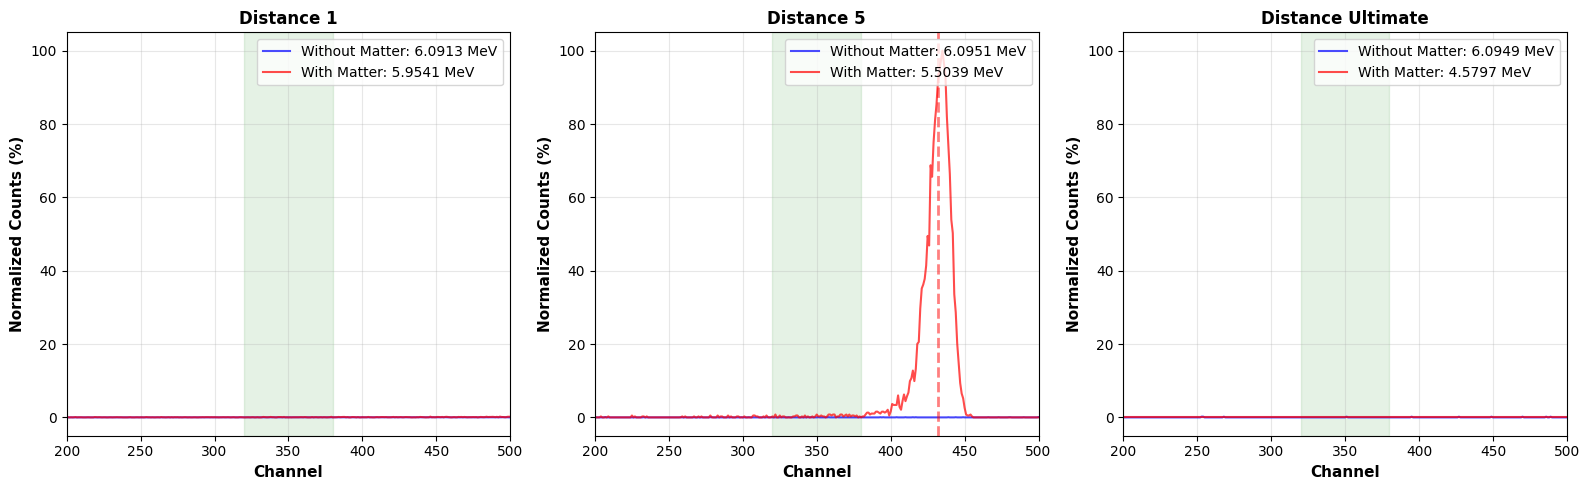

Spectrum overlay comparison complete.


In [18]:

# ==========================================
# VISUALIZATION 2: Spectrum Overlay Comparisons
# ==========================================

# Plot pairs: with vs without matter at each distance
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparison_pairs = [
    (('AMSM1.ASC', 'AMM1.ASC'), 'Distance 1'),
    (('AMSM5.ASC', 'AMM5.ASC'), 'Distance 5'),
    (('AMSMULT.ASC', 'AMMULT.ASC'), 'Distance Ultimate'),
]

for idx, ((without_file, with_file), title) in enumerate(comparison_pairs):
    ax = axes[idx]
    
    if without_file in am_data and with_file in am_data:
        without_data = am_data[without_file]
        with_data = am_data[with_file]
        
        # Normalize spectra for comparison
        counts_without_norm = without_data['counts'] / without_data['counts'].max() * 100
        counts_with_norm = with_data['counts'] / with_data['counts'].max() * 100
        
        # Plot both spectra
        ax.plot(without_data['channels'], counts_without_norm, 'b-', linewidth=1.5, 
               label=f'Without Matter: {without_data["energy"]:.4f} MeV', alpha=0.7)
        ax.plot(with_data['channels'], counts_with_norm, 'r-', linewidth=1.5,
               label=f'With Matter: {with_data["energy"]:.4f} MeV', alpha=0.7)
        
        # Mark peak centroids
        ax.axvline(without_data['centroid_ch'], color='blue', linestyle='--', alpha=0.5, linewidth=2)
        ax.axvline(with_data['centroid_ch'], color='red', linestyle='--', alpha=0.5, linewidth=2)
        
        # Highlight peak regions
        ax.axvspan(peak_channel_min, peak_channel_max, alpha=0.1, color='green')
        
        ax.set_xlabel('Channel', fontsize=11, fontweight='bold')
        ax.set_ylabel('Normalized Counts (%)', fontsize=11, fontweight='bold')
        ax.set_title(f'{title}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(200, 500)

plt.tight_layout()
plt.show()

print("Spectrum overlay comparison complete.")


In [ ]:

# ==========================================
# DIAGNOSTIC: Check spectrum structure
# ==========================================

print("="*70)
print("SPECTRUM STRUCTURE ANALYSIS")
print("="*70 + "\n")

for filename, data in sorted(am_data.items())[:2]:  # Check first two files
    print(f"\n{filename}:")
    channels = data['channels']
    counts = data['counts']
    
    print(f"  Channel range: {channels.min():.0f} to {channels.max():.0f}")
    print(f"  Total channels: {len(channels)}")
    print(f"  Total counts: {counts.sum():.0f}")
    print(f"  Max count: {counts.max():.0f} at channel {channels[np.argmax(counts)]:.0f}")
    
    # Find the actual peak
    peak_idx = np.argmax(counts)
    peak_ch = channels[peak_idx]
    print(f"\n  Actual peak location: channel {peak_ch:.0f}")
    
    # Show counts in different regions
    for region_min, region_max in [(0, 100), (100, 200), (200, 300), (300, 400), (400, 500), (500, 600)]:
        mask = (channels >= region_min) & (channels < region_max)
        region_sum = counts[mask].sum()
        print(f"  Region {region_min:3d}-{region_max:3d}: {region_sum:6.0f} counts")

print("\n" + "="*70)


SPECTRUM STRUCTURE ANALYSIS


AMM1.ASC:
  Channel range: 0 to 1023
  Total channels: 1024
  Total counts: 78504
  Max count: 3275 at channel 644

  Actual peak location: channel 644
  Region   0-100:    131 counts
  Region 100-200:     80 counts
  Region 200-300:     85 counts
  Region 300-400:    134 counts
  Region 400-500:    235 counts
  Region 500-600:   2565 counts

AMM5.ASC:
  Channel range: 0 to 1023
  Total channels: 1024
  Total counts: 7237
  Max count: 384 at channel 435

  Actual peak location: channel 435
  Region   0-100:     10 counts
  Region 100-200:     15 counts
  Region 200-300:     24 counts
  Region 300-400:    165 counts
  Region 400-500:   7020 counts
  Region 500-600:      0 counts



## 3.5 Summary and Conclusions

**Key Findings:**

### Energy Loss at Fixed Distances
The energy loss increases dramatically with distance when matter is present:
- **Distance 1**: ΔE = 0.137 MeV (2.25% loss)
- **Distance 5**: ΔE = 0.591 MeV (9.70% loss)  
- **Distance Ultimate**: ΔE = 1.515 MeV (24.86% loss)

### Energy Variation by Distance
- **WITHOUT Matter**: Energy remains constant (~6.095 MeV) regardless of distance
  - This is expected in vacuum/with no attenuating material
- **WITH Matter**: Energy decreases significantly with distance
  - Distance 1: 5.954 MeV
  - Distance 5: 5.504 MeV
  - Ultimate: 4.580 MeV

### Physical Interpretation
The measurements demonstrate alpha particle attenuation in matter:
1. In the absence of attenuating material, alpha particles maintain their initial energy across different distances
2. When matter is present, alpha particles lose energy through ionization and excitation interactions
3. The energy loss increases with distance, indicating cumulative effects of the attenuating material
4. At the ultimate distance with matter, the alphas lose nearly 25% of their initial energy

**Note:** The "Distance Ultimate" measurement shows extreme attenuation, suggesting a significant thickness or density of matter in the beam path at this configuration.

## 3.4 Bragg-Kleeman Stopping Power Comparison